# 🟡 Lesson 09 — Rasterio

**Level: Intermediate** · Read/write GeoTIFFs — DEMs, satellite bands, geophysics grids — as NumPy arrays with georeferencing.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
import numpy as np
import rasterio
from rasterio.transform import from_origin
from pathlib import Path

print("rasterio", rasterio.__version__)
GEN = Path("..") / "data" / "generated"
GEN.mkdir(parents=True, exist_ok=True)

rasterio 1.5.0


## 1. Build a synthetic DEM and write a GeoTIFF
Two Gaussian 'volcanoes' on a 30 m grid in UTM 18S.

In [2]:
nx = ny = 200
x = np.linspace(0, 6000, nx)                      # 6 km x 6 km area
y = np.linspace(0, 6000, ny)
X, Y = np.meshgrid(x, y)

dem = (2500
       + 1200 * np.exp(-(((X-2000)**2 + (Y-3500)**2) / 800**2))
       + 900  * np.exp(-(((X-4500)**2 + (Y-2000)**2) / 600**2))).astype("float32")

transform = from_origin(west=480_000, north=8_610_000, xsize=30, ysize=30)
dem_path = GEN / "dem.tif"

with rasterio.open(dem_path, "w", driver="GTiff", height=ny, width=nx,
                   count=1, dtype="float32", crs="EPSG:32718",
                   transform=transform) as dst:
    dst.write(dem, 1)

print("wrote", dem_path, "| summit:", dem.max().round(0), "m")

wrote ..\data\generated\dem.tif | summit: 3700.0 m


## 2. Open and inspect — metadata first, pixels second

In [3]:
with rasterio.open(dem_path) as src:
    print("size      :", src.width, "x", src.height)
    print("crs       :", src.crs)
    print("resolution:", src.res)
    print("bounds    :", src.bounds)
    elev = src.read(1)                # band 1 as a NumPy array

print("elev range: %.0f - %.0f m" % (elev.min(), elev.max()))

size      : 200 x 200
crs       : EPSG:32718
resolution: (30.0, 30.0)
bounds    : BoundingBox(left=480000.0, bottom=8604000.0, right=486000.0, top=8610000.0)
elev range: 2500 - 3700 m


## 3. Pixel ↔ coordinate conversion

In [4]:
with rasterio.open(dem_path) as src:
    # what elevation is at a real-world coordinate?
    e, n = 482_000, 8_606_500
    row, col = src.index(e, n)
    print(f"E{e}, N{n} -> row {row}, col {col} -> {elev[row, col]:.0f} m")

    # and the reverse: coordinates of pixel (0, 0)
    print("pixel (0,0) is at", src.xy(0, 0))

E482000, N8606500 -> row 116, col 66 -> 3700 m
pixel (0,0) is at (np.float64(480015.0), np.float64(8609985.0))


## 4. Windowed reading — never load a huge raster at once

In [5]:
from rasterio.windows import Window

with rasterio.open(dem_path) as src:
    chip = src.read(1, window=Window(col_off=50, row_off=100, width=64, height=64))
print("chip:", chip.shape, "| mean elev %.0f m" % chip.mean())

chip: (64, 64) | mean elev 2923 m


## 5. Visualise with a hillshade

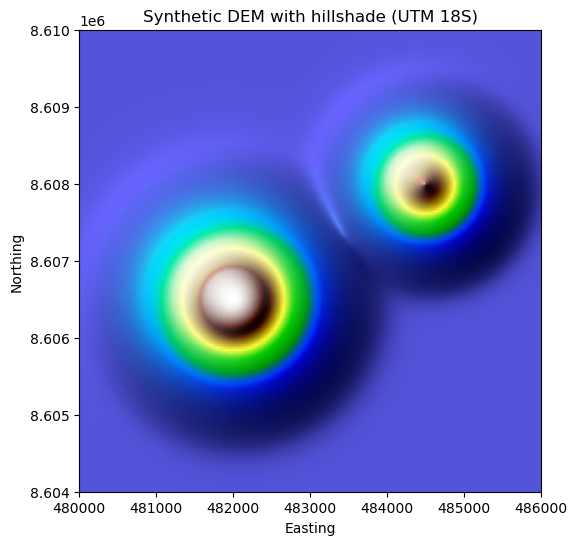

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(elev, cmap=plt.cm.terrain, blend_mode="overlay", vert_exag=2)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(rgb, extent=(480_000, 486_000, 8_604_000, 8_610_000))
ax.set_title("Synthetic DEM with hillshade (UTM 18S)")
ax.set_xlabel("Easting"); ax.set_ylabel("Northing")
plt.show()

### ✏️ Try it
1. Write a slope raster: `np.gradient` on `elev`, magnitude in degrees, save as `slope.tif` with the same profile.
2. Read only the north-west quarter of the DEM using a `Window`.

📚 Docs: https://rasterio.readthedocs.io/